In [1]:
# for reload python packages under development
%load_ext autoreload
%autoreload 2

# if add new modules, then do
# %reload_ext autoreload
# %autoreload 2    

In [2]:
import torch
import numpy


In [3]:
import pickle

# with open('Xs_samples.pkl', 'wb') as f:
#     pickle.dump(Xs, f)

# this is blood stem cell data
# Load later with:
# Obtain from 7_iNMF_prepareXs.ipynb
# Load later with:
# with open('Xs_samples.pkl', 'rb') as f:
#     Xs = pickle.load(f)

# raw counts
# Obtain from 7_iNMF_prepareXs.ipynb
# Load later with:
with open('Xs_samples_raw.pkl', 'rb') as f:
    Xs_raw = pickle.load(f)
    

In [4]:
import pandas as pd
import os 
from skbio.stats.composition import closure, multiplicative_replacement, ilr, ilr_inv, clr
import numpy as np

org_dir = "/home/lel2/luan/projects/cell_tissue_phenotype/results/normal_HSC/pseudobulk/refined/"
method = "max_counts"

cell_type_proportions_df = pd.read_csv(
        # "/data1/soldatr/luan/projects/cell_tissue_phenotype/results/normal_HSC/cell_type_proportions_harmony_sample_id.csv",
        # "/data1/soldatr/luan/projects/cell_tissue_phenotype/results/normal_HSC/cell_type_proportions_harmony_sample_id_avg_pseudobulk.csv",
        # "/data1/soldatr/luan/projects/cell_tissue_phenotype/results/normal_HSC/pseudobulk/max_counts/parallel/cell_type_proportions_pseudobulk_max_counts.csv",
        # "/home/lel2/luan/projects/cell_tissue_phenotype/results/normal_HSC/pseudobulk/weighted_ncells/cell_type_proportions_pseudobulk_max_counts.csv",
        os.path.join(org_dir, f"{method}/mean_gene_expression/cell_type_proportions_pseudobulk_{method}.csv"),
        index_col=0
    )

meta = pd.read_csv("/home/lel2/luan/projects/cell_tissue_phenotype/results/normal_HSC/pseudobulk/refined/max_counts/mean_gene_expression/metadata_samples_pseudobulk_max_counts.csv")

assert(np.all(cell_type_proportions_df.index == meta["sample_id"]))

In [5]:
# Covariates: sex (one-hot, drop_first) and ages
Z = pd.get_dummies(meta[['sex_src']], prefix='sex_src', drop_first=True)
Z['ages'] = meta['ages'].astype(float)
Z = Z.astype(float)
Z.index = meta.index  # align

In [6]:
from regression.preprocessing import CompositionalILR

# 1) Infer problem dims
gene_dim = Xs_raw[0].shape[1]
num_targets = cell_type_proportions_df.shape[1]

# ilr-transform cell type proportions
ilr_tx = CompositionalILR(zero_replacement=True).fit(cell_type_proportions_df.values)
Y_imp_ilr = ilr_tx.transform(cell_type_proportions_df.values)  # replace your earlier line



/data1/soldatr/luan/projects/cell_tissue_phenotype/uv_env/.venv/lib/python3.11/site-packages/skbio/util/_warning.py:40: DeprecationWarning: `multiplicative_replacement` was renamed to `multi_replace` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


In [16]:
import torch
import torch.nn as nn
from typing import Dict, Optional


def evaluate_on_loader(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
    recenter_y: bool = False,
    y_mean: Optional[torch.Tensor] = None,
    return_compositions: bool = True,
    method: str = "predict_ilr",  # or "softmax_celltype", "softmax_ilr"
) -> Dict[str, torch.Tensor]:
    """
    Run model on a loader and return predictions and targets aligned to dataset indices.

    Returns a dict with:
      - "preds": (S, T) predictions (ILR or composition, depending on method and flags)
      - "targets": (S, T) targets from the dataset (as provided by loader)
      - optionally "preds_comp": (S, K) compositions (if return_compositions=True and method outputs ILR)
    """
    model.eval()

    # Figure out S and T from the dataset and a sample batch
    S = len(loader.dataset)
    # Peek first batch to get output dims
    first_batch = next(iter(loader))
    # Unpack consistent with your collate: (X_cells, cell_to_batch, Z, Y_batch, sample_idx_batch)
    _, _, _, Yb0, sample_idx_batch0 = first_batch
    T = Yb0.shape[1]  # target dimensionality (e.g., K or K-1)

    preds_all = torch.empty((S, T), dtype=torch.float32)
    targets_all = torch.empty((S, T), dtype=torch.float32)

    # If you will add back y_mean (for centered ILR), move it to device once
    y_mean_dev = None
    if recenter_y and y_mean is not None:
        y_mean_dev = y_mean.to(device=device, dtype=torch.float32)

    with torch.inference_mode():
        for Xb, cell_to_batch, Zb, Yb, sample_idx_batch in loader:
            # Move tensors to device; the model will handle preprocessing
            Xb = Xb.to(device=device, dtype=getattr(model, "dtype", torch.float32), non_blocking=True)
            Zb = Zb.to(device=device, dtype=getattr(model, "dtype", torch.float32), non_blocking=True)
            cell_to_batch = cell_to_batch.to(device=device, non_blocking=True)
            sample_idx_batch = sample_idx_batch.to(device=device, non_blocking=True)
            Yb = Yb.to(device=device, dtype=torch.float32, non_blocking=True)

            # Forward pass
            preds = model(Xb, Zb, cell_to_batch, sample_idx_batch)  # shape (B, T) at sample level

            # If you centered ILR during training, add back mean here for fair comparison
            if recenter_y and y_mean_dev is not None:
                preds = preds.float() + y_mean_dev  # ensure float32 for addition

            # Move to CPU and place rows by sample_idx_batch (these are dataset-local indices 0..S-1)
            idx = sample_idx_batch.cpu().long()
            preds_all[idx] = preds.detach().cpu().float()
            targets_all[idx] = Yb.detach().cpu().float()

    out = {"preds": preds_all, "targets": targets_all}

    # Optionally return compositions if the model outputs ILR (predict_ilr or softmax_ilr)
    if return_compositions and method in ("predict_ilr", "softmax_ilr"):
        # Invert ILR to compositions
        from regression.neural_network.ilr_torch import ilr_transform_inverse
        out["preds_comp"] = ilr_transform_inverse(preds_all, dim=1)  # (S, K)
        out["targets_comp"] = ilr_transform_inverse(targets_all, dim=1)  # (S, K)

    return out

In [8]:
# Build datasets using explicit index arrays (no random fractions inside)
from typing import Dict, Optional, Union, List
import numpy as np
import torch
from regression.neural_network.data_utils import SampleCellsDataset

def build_datasets_from_indices(
    method: str,
    Xs_raw: List,                                  # list of S sample matrices
    Z: Union[np.ndarray, "pd.DataFrame"],          # (S, C)
    Y_imp_ilr: Optional[np.ndarray],               # (S, T_ilr) or None
    cell_type_proportions_df: Optional[Union[np.ndarray, "pd.DataFrame"]],
    indices: Dict[str, np.ndarray],                # keys: 'train', 'val' (and optionally 'test')
    dtype: torch.dtype = torch.float32,
):
    Z_np = np.asarray(Z, dtype=np.float32)

    datasets = {}
    extras = {}

    if method == "ilr_recenter":
        assert Y_imp_ilr is not None, "Y_imp_ilr must be provided for ilr_recenter."
        Y_ilr_np = np.asarray(Y_imp_ilr, dtype=np.float32)
        Y_train_mean = Y_ilr_np[indices["train"], :].mean(axis=0)
        extras["Y_train_mean"] = Y_train_mean
        Y_centered = Y_ilr_np - Y_train_mean
        for split in ("train", "val", "test"):
            if split not in indices:
                continue
            idx = indices[split]
            datasets[split] = SampleCellsDataset(
                [Xs_raw[i] for i in idx.tolist()],
                Z_np[idx, :],
                Y_centered[idx, :],
                dtype=dtype,
            )
        return datasets, extras

    if method.endswith("ilr"):
        assert Y_imp_ilr is not None, "Y_imp_ilr must be provided for ILR methods."
        Y_ilr_np = np.asarray(Y_imp_ilr, dtype=np.float32)
        for split in ("train", "val", "test"):
            if split not in indices:
                continue
            idx = indices[split]
            datasets[split] = SampleCellsDataset(
                [Xs_raw[i] for i in idx.tolist()],
                Z_np[idx, :],
                Y_ilr_np[idx, :],
                dtype=dtype,
            )
        extras["Y_train_mean"] = Y_ilr_np[indices["train"], :].mean(axis=0)
    else:
        assert cell_type_proportions_df is not None, "cell_type_proportions_df required for composition methods."
        Y_comp_np = np.asarray(cell_type_proportions_df, dtype=np.float32)
        for split in ("train", "val", "test"):
            if split not in indices:
                continue
            idx = indices[split]
            datasets[split] = SampleCellsDataset(
                [Xs_raw[i] for i in idx.tolist()],
                Z_np[idx, :],
                Y_comp_np[idx, :],
                dtype=dtype,
            )

    return datasets, extras

In [9]:
# kfold_splits.py
import numpy as np
from typing import List, Dict, Optional
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold

def make_kfold_train_val_test_indices(
    S: int,
    n_splits: int = 5,
    seed: int = 0,
    shuffle: bool = True,
    y_strat: Optional[np.ndarray] = None,   # shape (S,), for stratified folds
    groups: Optional[np.ndarray] = None,    # shape (S,), for grouped folds
    val_offset: int = 1                     # which fold to use as val relative to test fold
) -> List[Dict[str, np.ndarray]]:
    """
    Produce K disjoint train/val/test splits:
      - For fold f, test = folds[f], val = folds[(f + val_offset) % K], train = rest.
    All folds are disjoint; across folds, every sample appears once as test and once as val.

    Args:
      S: number of samples.
      n_splits: number of folds (must be >= 3 for non-empty train).
      seed, shuffle: passed to splitter.
      y_strat: optional labels for StratifiedKFold (mutually exclusive with groups).
      groups: optional group IDs for GroupKFold (mutually exclusive with y_strat).
      val_offset: 1 uses the next fold as validation; can be >1 if you want a gap.

    Returns:
      List of dicts, each with keys: 'train', 'val', 'test'.
    """
    if n_splits < 3:
        raise ValueError("n_splits must be >= 3 to create disjoint train/val/test per fold.")

    indices = np.arange(S)

    # Build base folds as a list of test-index arrays (disjoint, near-equal sizes)
    if y_strat is not None and groups is not None:
        raise ValueError("Provide either y_strat (stratified) or groups (grouped), not both.")
    if y_strat is not None:
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=seed)
        folds = [test_idx for _, test_idx in splitter.split(indices, y_strat)]
    elif groups is not None:
        splitter = GroupKFold(n_splits=n_splits)
        folds = [test_idx for _, test_idx in splitter.split(indices, groups=groups)]
    else:
        splitter = KFold(n_splits=n_splits, shuffle=shuffle, random_state=seed)
        folds = [test_idx for _, test_idx in splitter.split(indices)]

    # Build (train, val, test) per fold
    out: List[Dict[str, np.ndarray]] = []
    for f in range(n_splits):
        test_idx = folds[f]
        val_idx = folds[(f + val_offset) % n_splits]
        # train = all others
        train_idx = np.concatenate([folds[i] for i in range(n_splits) if i not in {f, (f + val_offset) % n_splits}])
        out.append({"train": train_idx, "val": val_idx, "test": test_idx})

    return out

In [10]:
from dataclasses import dataclass
import torch
import numpy as np
from torch.nn import Module
from typing import Any, Dict
from regression.neural_network.dataclass_models import DataInputs, ModelHyperparams, TrainSetup

# @dataclass
# class DataInputs:
#     """Groups raw data inputs."""
#     Xs_raw: Any  # Replace with actual type (e.g., list of tensors or DataFrame)
#     Z: Any  # e.g., pd.DataFrame
#     Y_imp_ilr: Any  # e.g., np.ndarray or torch.Tensor
#     cell_type_proportions_df: Any  # e.g., pd.DataFrame

# @dataclass
# class ModelHyperparams:
#     """Groups model architecture hyperparameters."""
#     hidden_features: Any  # e.g., int or list[int]
#     num_hidden_layers: int
#     activation: bool
#     dropout: Any  # e.g., float or list[float] or None
#     batch_norm: bool  # Renamed from batchnorm for consistency
#     bias: bool
#     scaling_factor: float
#     method: str

# @dataclass
# class TrainSetup:
#     """Groups training setup parameters."""
#     batch_size: int
#     device: torch.device
#     epochs: int
#     lr: float
#     weight_decay: float

def run_one_fold(data: DataInputs, hyperparams: ModelHyperparams, setup: TrainSetup, fold: int, fold_idxs: Dict[str, Any]) -> Dict[str, Any]:
    '''
    DataInputs: a DataClass storing data for training
    hyperparams: a DataClass storing MLP architecture parameters
    setup: a DataClass storing parameters to run the MLP
    fold: the fold ordering (e.g., 0, 1, 2)
    fold_idxs: storing indices of samples for training, validating and testing
    '''
    
    # Unpack for clarity 
    Xs_raw = data.Xs_raw
    Z = data.Z
    Y_imp_ilr = data.Y_imp_ilr
    cell_type_proportions_df = data.cell_type_proportions_df
    
    hidden_features = hyperparams.hidden_features
    num_hidden_layers = hyperparams.num_hidden_layers
    activation = hyperparams.activation
    dropout = hyperparams.dropout
    batch_norm = hyperparams.batch_norm
    bias = hyperparams.bias
    scaling_factor = hyperparams.scaling_factor
    method = hyperparams.method
    layer_norm = hyperparams.layer_norm 
    loss_fn = hyperparams.loss_fn
    loss_fn_kwargs = hyperparams.loss_fn_kwargs
    activation_type = hyperparams.activation_type
    
    
    batch_size = setup.batch_size
    device = setup.device
    epochs = setup.epochs
    lr = setup.lr
    weight_decay = setup.weight_decay
    
    # Build datasets for this fold
    datasets, extras = build_datasets_from_indices(
        method=method,
        Xs_raw=Xs_raw,
        Z=Z,
        Y_imp_ilr=Y_imp_ilr,
        cell_type_proportions_df=cell_type_proportions_df,
        indices=fold_idxs,
        dtype=torch.float32,
    )
    # Build loaders (use your compact collate)
    loaders = build_loaders(datasets, batch_size=batch_size, 
                            num_workers=1, 
                            pin_memory=True, 
                            collate_fn=collate_samples_compact)
    
    loader = loaders["train"]
    loader_val = loaders["val"]
    loader_test = loaders["test"]
    
    # Recompute training-only stats per fold
    # calculate across all cells presence in the minibatches

    gene_mean, gene_std = compute_cellwise_stats(loader, device="cpu")
    tol = 1e-6
    gene_mask = (gene_std > tol)
    G_kept = int(gene_mask.sum().item())
    C = np.asarray(Z).shape[1]
    in_features = G_kept + C
    out_features = (Y_imp_ilr.shape[1] if method.endswith("ilr") else np.asarray(cell_type_proportions_df).shape[1])
    age_column_id = Z.columns.tolist().index('ages')
    train_idx = fold_idxs['train']
    age_mean = Z.iloc[train_idx]['ages'].mean()
    age_std = Z.iloc[train_idx]['ages'].std()
    
    # Build preprocessor and model for this fold
    pre = Preprocessor(gene_mask=gene_mask.to(device=device),
                       gene_mean=gene_mean.to(device=device),
                       gene_std=gene_std.to(device=device),
                       cont_cov_mask=age_column_id,
                       cov_mean=torch.tensor(age_mean).to(device=device),
                       cov_std=torch.tensor(age_std).to(device=device),
                       scaling_factor=scaling_factor,
                       normalize=True)
   
    model = CompositionModel(
        in_features=in_features,
        out_features=out_features,
        method=method,
        aggregator_mode="mean",
        preprocessor=pre,
        hidden_features=hidden_features, num_hidden_layers=num_hidden_layers, activation=activation,
        dropout=dropout, batch_norm=batch_norm, bias=bias, dtype=torch.float32,
    )
    # Train on this device
    trainer = Trainer(model, loader, loader_val,
                      lr=lr, weight_decay=weight_decay,
                      epochs=epochs, recenter_y=(method == "ilr_recenter"),
                      device=device, dtype=torch.float32, verbose=True,
                      patience = 10,
                      min_delta = 1e-3,
                      use_lr_scheduler = False, 
                      min_epochs = 20, # for saving best state since epochs 20 onwards
                      )
    trainer.fit()
    # Evaluate on test
    from torch.nn.functional import mse_loss
    test_res = evaluate_on_loader(trainer.model, loader_test, device=trainer.device,
                                  recenter_y=trainer.recenter_y, y_mean=trainer.y_mean,
                                  return_compositions=True, method=method)
    test_mse = mse_loss(test_res["preds"], test_res["targets"], reduction="mean").item()
    return {"fold": fold,
            "test_res": test_res,
            'trainer': trainer,
            "test_mse": test_mse}

In [11]:
# for checking the scripts
from regression.neural_network import Preprocessor, Aggregator, Postprocessor, CellPredictor, CompositionModel, Trainer
from regression.neural_network.data_utils import collate_samples_compact, compute_cellwise_stats
from regression.neural_network import build_datasets, build_loaders


In [12]:
# for linear
recenter_y = False
bias = not recenter_y
num_hidden_layers = 0
hidden_features = 10
scaling_factor = 1e4
batch_size = 8
epochs = 1000
lr = 1e-3
weight_decay = 1e-3
method = 'predict_ilr'
activation = False
dropout = 0
batch_norm = False
device = 'cuda'

In [13]:
# for nonlinear

recenter_y = False
bias = not recenter_y
num_hidden_layers = 2
hidden_features = [512, 10]
scaling_factor = 1e4
batch_size = 8
epochs = 1000
lr = 1e-3
weight_decay = 1e-3
activation = True
dropout = 0
batch_norm = True
device = 'cuda'

In [21]:
layer_norm = True
loss_fn = nn.MSELoss()
loss_fn_kwargs = {'reduction': 'mean'}
activation_type = None

In [17]:
# for quick test
# Build K disjoint train/val/test splits
Xs_raw_test = Xs_raw[:10]
S = len(Xs_raw_test) # for quick check 
folds = make_kfold_train_val_test_indices(S, n_splits=5, seed=0, shuffle=True)
all_val_mse = []
all_test_mse = []


layer_norm = True
loss_fn = nn.MSELoss()
loss_fn_kwargs = {'reduction': 'mean'}
activation_type = None
use_lr_scheduler = False

data = DataInputs(Xs_raw=Xs_raw_test,
                  # Xs_raw=Xs_raw,
                  Z=Z, 
                  Y_imp_ilr=Y_imp_ilr, 
                  cell_type_proportions_df=cell_type_proportions_df)

hyperparams = ModelHyperparams(hidden_features=hidden_features, 
                               num_hidden_layers=num_hidden_layers,
                               activation=activation,
                               dropout=dropout,
                               batch_norm=batch_norm,
                               bias=bias, 
                               scaling_factor=scaling_factor, 
                               method=method,
                               layer_norm=layer_norm,
                               loss_fn=loss_fn,
                               loss_fn_kwargs=loss_fn_kwargs,
                               activation_type=activation_type)

setup = TrainSetup(batch_size=batch_size, 
                   device=device,
                   epochs=10,
                   lr=lr,
                   weight_decay=weight_decay,
                   use_lr_scheduler=use_lr_scheduler)
result = run_one_fold(data, hyperparams, setup, fold=0, fold_idxs=folds[0])


 10%|█         | 1/10 [00:01<00:12,  1.34s/it]

Epoch 1: train_mse=3.168e+00, val_mse=2.546e+00


100%|██████████| 10/10 [00:07<00:00,  1.32it/s]


In [18]:
result['trainer'].model

CompositionModel(
  (preprocessor): Preprocessor()
  (aggregator): Aggregator()
  (postprocessor): Postprocessor()
  (cell_predictor): CellPredictor(
    (network): Sequential(
      (0): Linear(in_features=16617, out_features=16, bias=True)
    )
  )
)

In [22]:
from regression.neural_network.data_utils import make_outerkfold_inner_split
# for complete run
# Build K disjoint train/val/test splits

S = len(Xs_raw) 
# folds = make_kfold_train_val_test_indices(S, n_splits=5, seed=0, shuffle=True)
n_splits = 5
seed = 0
folds = make_outerkfold_inner_split(S, n_splits=n_splits, seed=seed, shuffle=True, inner_val_frac_of_trainval=0.20)

all_val_mse = []
all_test_mse = []


data = DataInputs(Xs_raw=Xs_raw,
                  Z=Z, 
                  Y_imp_ilr=Y_imp_ilr, 
                  cell_type_proportions_df=cell_type_proportions_df)

hyperparams = ModelHyperparams(hidden_features=hidden_features, 
                               num_hidden_layers=num_hidden_layers,
                               activation=activation,
                               dropout=dropout,
                               batch_norm=batch_norm,
                               bias=bias, 
                               scaling_factor=scaling_factor, 
                               method=method,
                               layer_norm=layer_norm,
                               loss_fn=loss_fn,
                               loss_fn_kwargs=loss_fn_kwargs,
                               activation_type=activation_type)

setup = TrainSetup(batch_size=batch_size, 
                   device=device,
                   epochs=epochs,
                   lr=lr,
                   weight_decay=weight_decay,
                   use_lr_scheduler=use_lr_scheduler)


In [25]:
folds[0]

{'train': array([ 70,  56, 114,  96, 210,  62,  76, 181, 120,  68, 215,  17,  69,
        165,  80, 213, 220, 135,  81,  58,  23, 105, 103, 198, 170, 130,
         88, 113, 142, 116,  50,  13, 158, 211, 122, 191, 100,  67,  98,
         43, 124, 180,  47,  72,  40,   0,  59, 224,  35,  84,  61, 148,
        119, 102,  74, 216,  33,  77, 223, 173, 194, 221, 138, 201, 172,
        209, 171,  29,  99,  82, 214,  30,  86,  39, 152, 208,  51, 136,
        177,  16,  57, 115,  94, 188, 192, 110, 218, 185, 169,  20,  65,
        141,  78,   6,  38,  25,  27, 212, 154,  22,   4, 123,  28,  21,
        109, 162, 205,  14, 155,  95,  66, 219,  34, 174,  79,  24, 196,
        163, 167, 200, 127,  91, 186, 132, 206,  73, 160, 140, 150,  49,
         10, 175,  83,   2,   1, 199, 112, 182,  46, 133,  26,  60, 157,
        146]),
 'val': array([ 54,  45, 184,  42, 147,  53,  19,  11, 204, 195, 164,  31, 222,
        117,   9,  71, 151,  32, 189,  52,   3, 129, 118, 217,  48, 128,
        203,  85,  3

In [26]:
from regression.neural_network import Preprocessor, Aggregator, Postprocessor, CellPredictor, CompositionModel, Trainer
from regression.neural_network.data_utils import collate_samples_compact, compute_cellwise_stats
import pickle
import os 

result = {}
# save in forloop/linear
file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/forloop/linear'
file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/forloop/linear_redo'

# save in forloop/nonlinear
# file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/forloop/non_linear'


os.makedirs(file_dir, exist_ok=True)

filename_pkl = "forloopMLP"

# have early stopping to speed things up 
for k, fold_idxs in enumerate(folds, start=1):
    fold = k 
    result[f'Fold_{fold}'] = run_one_fold(data, hyperparams, setup, fold=fold, fold_idxs=fold_idxs)
    with open(os.path.join(file_dir, f"{filename_pkl}_{fold}.tmp"), "wb") as f:
        pickle.dump(result[f'Fold_{fold}'], f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(os.path.join(file_dir, f"{filename_pkl}_{fold}.tmp"), os.path.join(file_dir, f"{filename_pkl}_{fold}.pkl"))

  0%|          | 1/1000 [00:05<1:28:14,  5.30s/it]

Epoch 1: train_mse=2.592e+00, val_mse=2.337e+00


  4%|▍         | 39/1000 [03:33<1:27:41,  5.47s/it]

Early stopping at epoch 40. Best epoch was 30 with val_mse=9.984e-01



  0%|          | 1/1000 [00:06<1:44:46,  6.29s/it]

...

Epoch 50: train_mse=4.324e-01, val_mse=9.411e-01


 10%|█         | 100/1000 [11:24<1:43:12,  6.88s/it]

Epoch 100: train_mse=1.041e-01, val_mse=6.105e-01


 12%|█▏        | 117/1000 [13:26<1:41:26,  6.89s/it]

Early stopping at epoch 118. Best epoch was 108 with val_mse=5.736e-01


# check individual fold

In [27]:
import pickle
import os

filename_pkl = "forloopMLP"

file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/forloop/linear'
file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/forloop/non_linear'
file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/forloop/linear_redo'



fold = 4
file_path = os.path.join(file_dir, f"{filename_pkl}_{fold}.pkl")

with open(file_path, 'rb') as f:
    result = pickle.load(f)

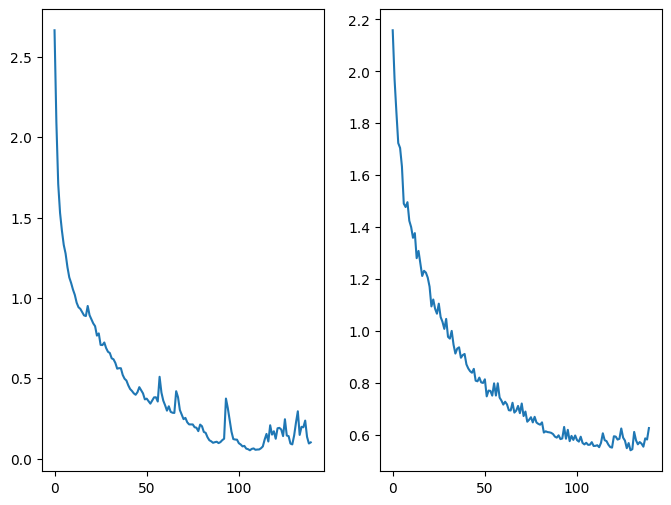

In [28]:

import matplotlib.pyplot as plt

trainer = result['trainer']
plt.figure(figsize = (8,6))
plt.subplot(1,2,1)
plt.plot(trainer.train_mse_history)
plt.subplot(1,2,2)
plt.plot(trainer.val_mse_history)



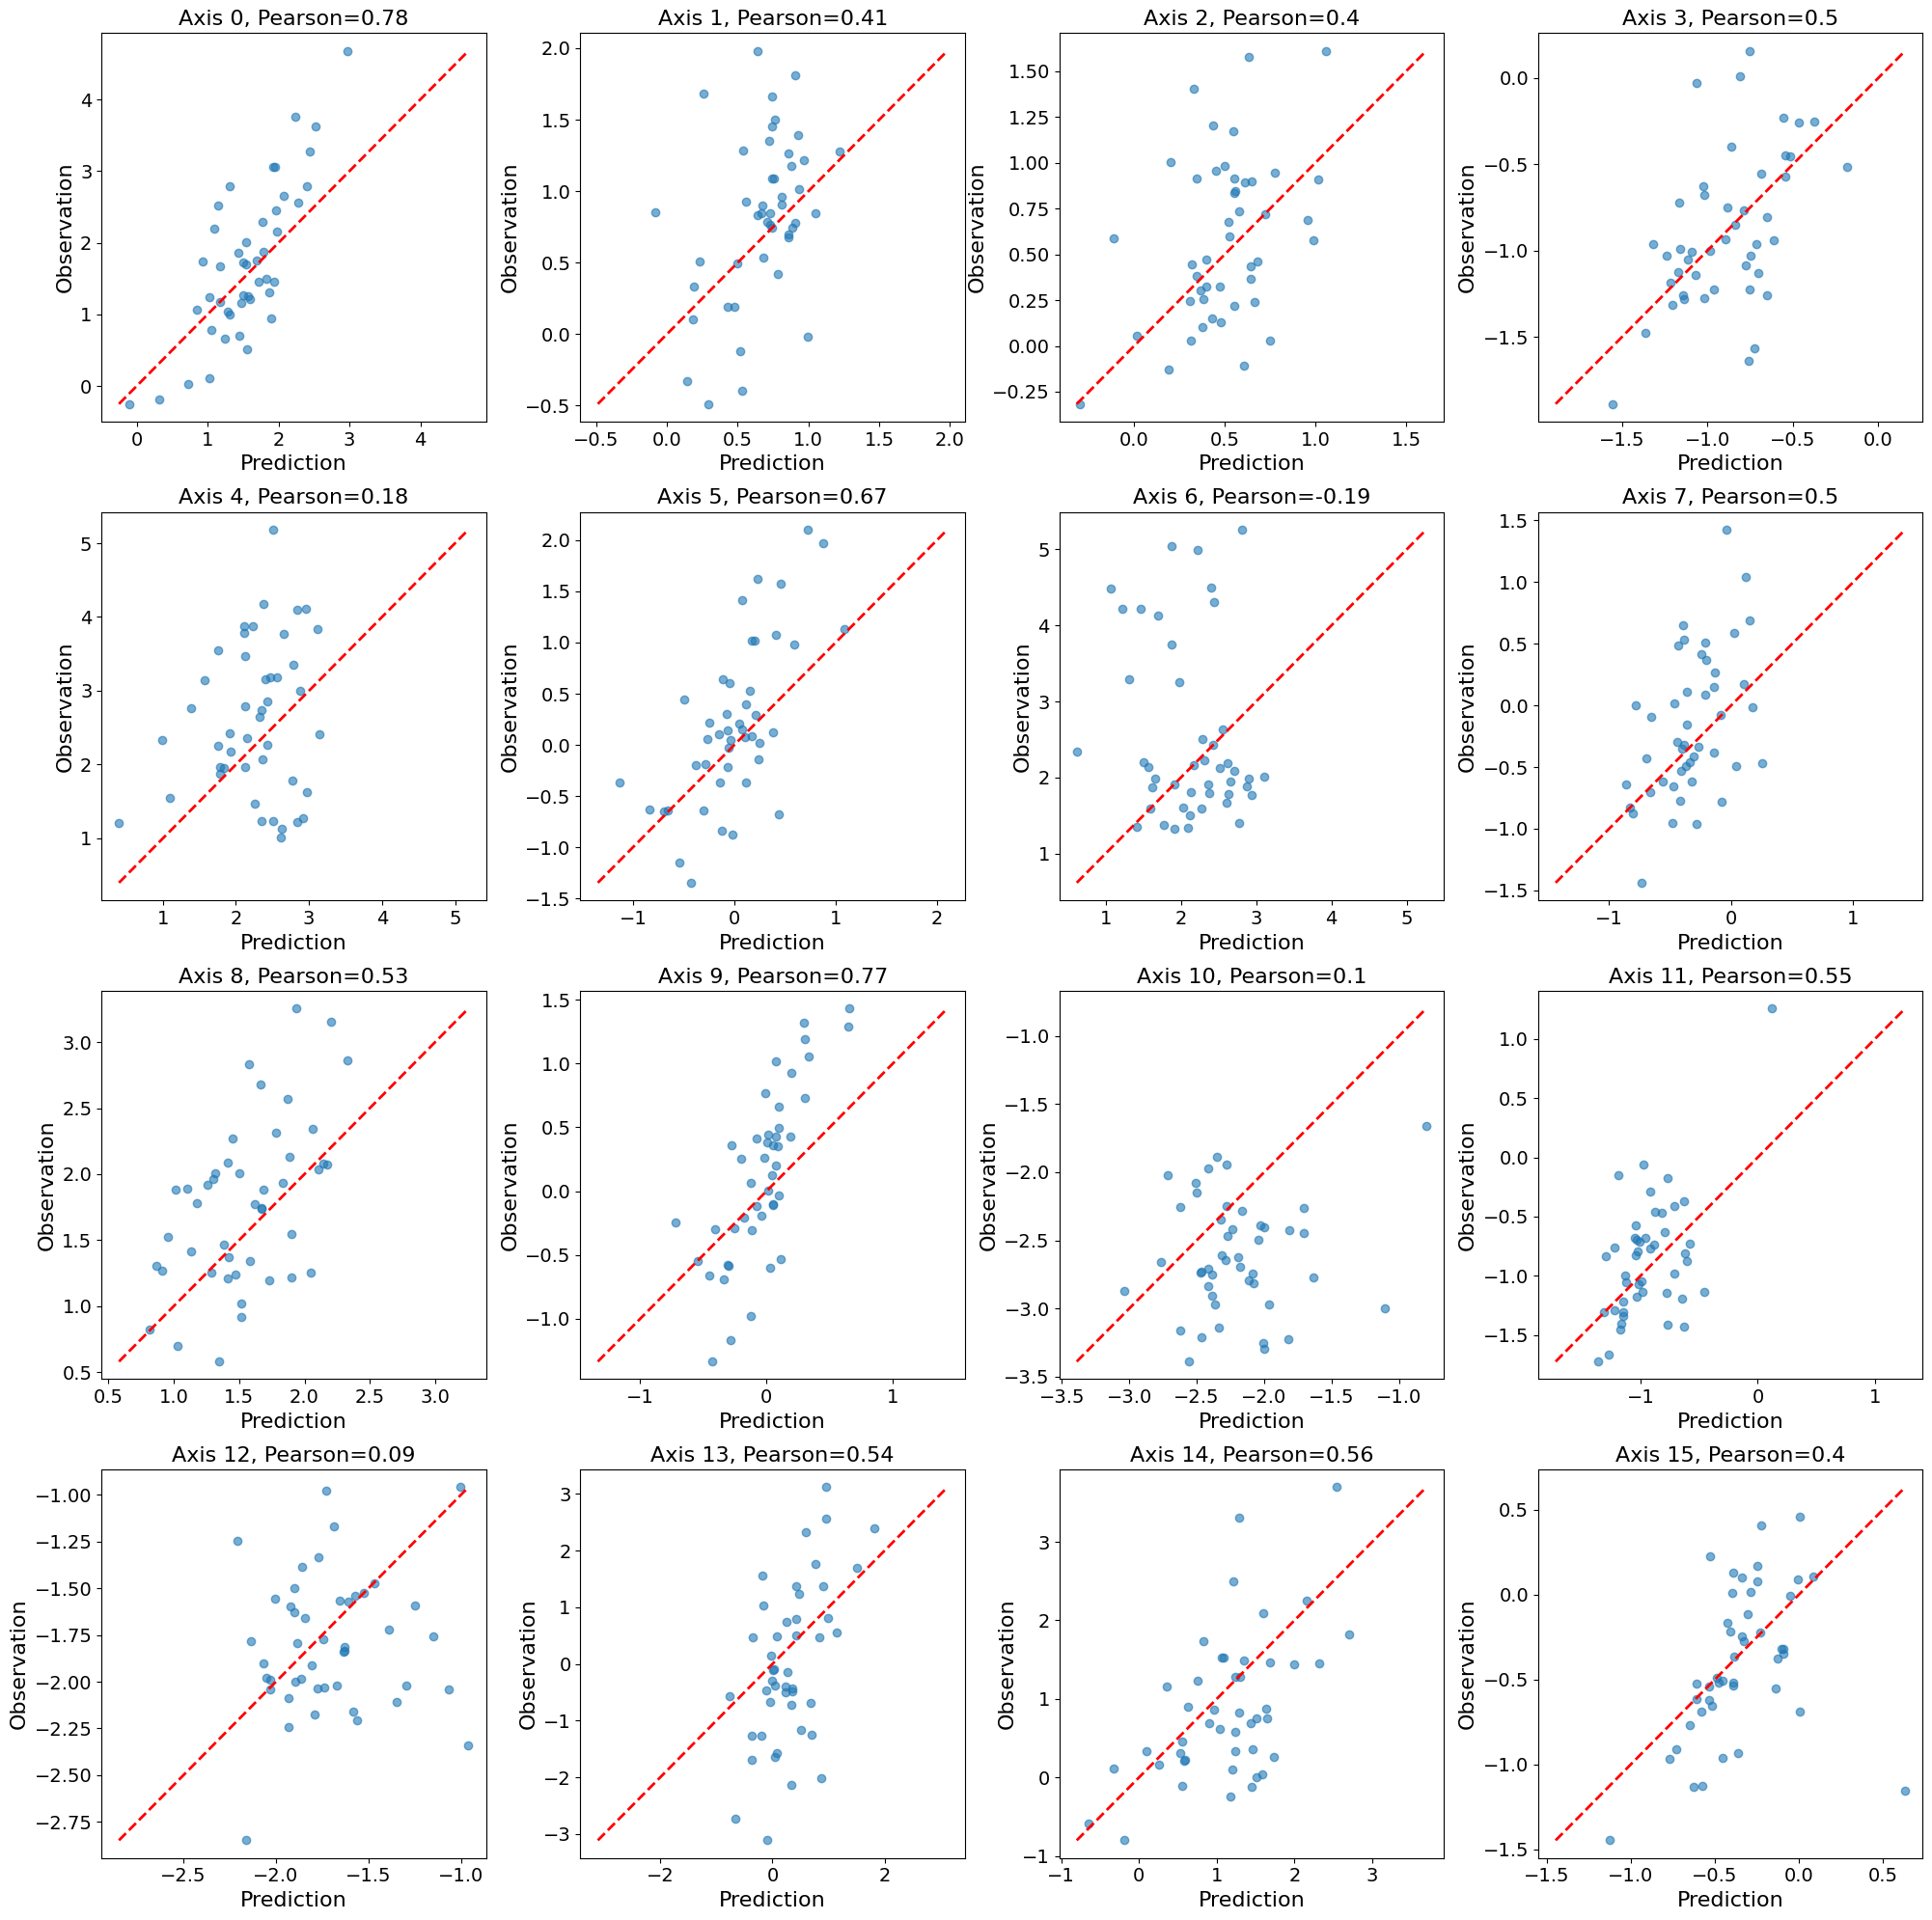

In [65]:
# targets = result['Fold_3']['test_res']['targets']
# preds = result['Fold_3']['test_res']['preds']

targets = result['test_res']['targets']
preds = result['test_res']['preds']

test_targets = targets.numpy()
test_preds = preds.numpy()

ncols = 4
nrows = round(test_targets.shape[1]/ncols) 

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(test_targets.shape[1]):
    axs[i].scatter(test_preds[:,i].ravel(), test_targets[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction', fontsize = 16)
    axs[i].set_ylabel('Observation', fontsize = 16)
    axs[i].tick_params(axis = 'both', labelsize = 14)
    # axs[i].set_xscale('log')
    # axs[i].set_yscale('log')
    # axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}")
    axs[i].set_title(f"Axis {i}, Pearson={np.round(np.corrcoef(test_preds[:, i], test_targets[:, i])[0][1], decimals = 2)}", fontsize = 16)
    min_val = min(test_preds[:, i].min(), test_targets[:, i].min())
    max_val = max(test_preds[:, i].max(), test_targets[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

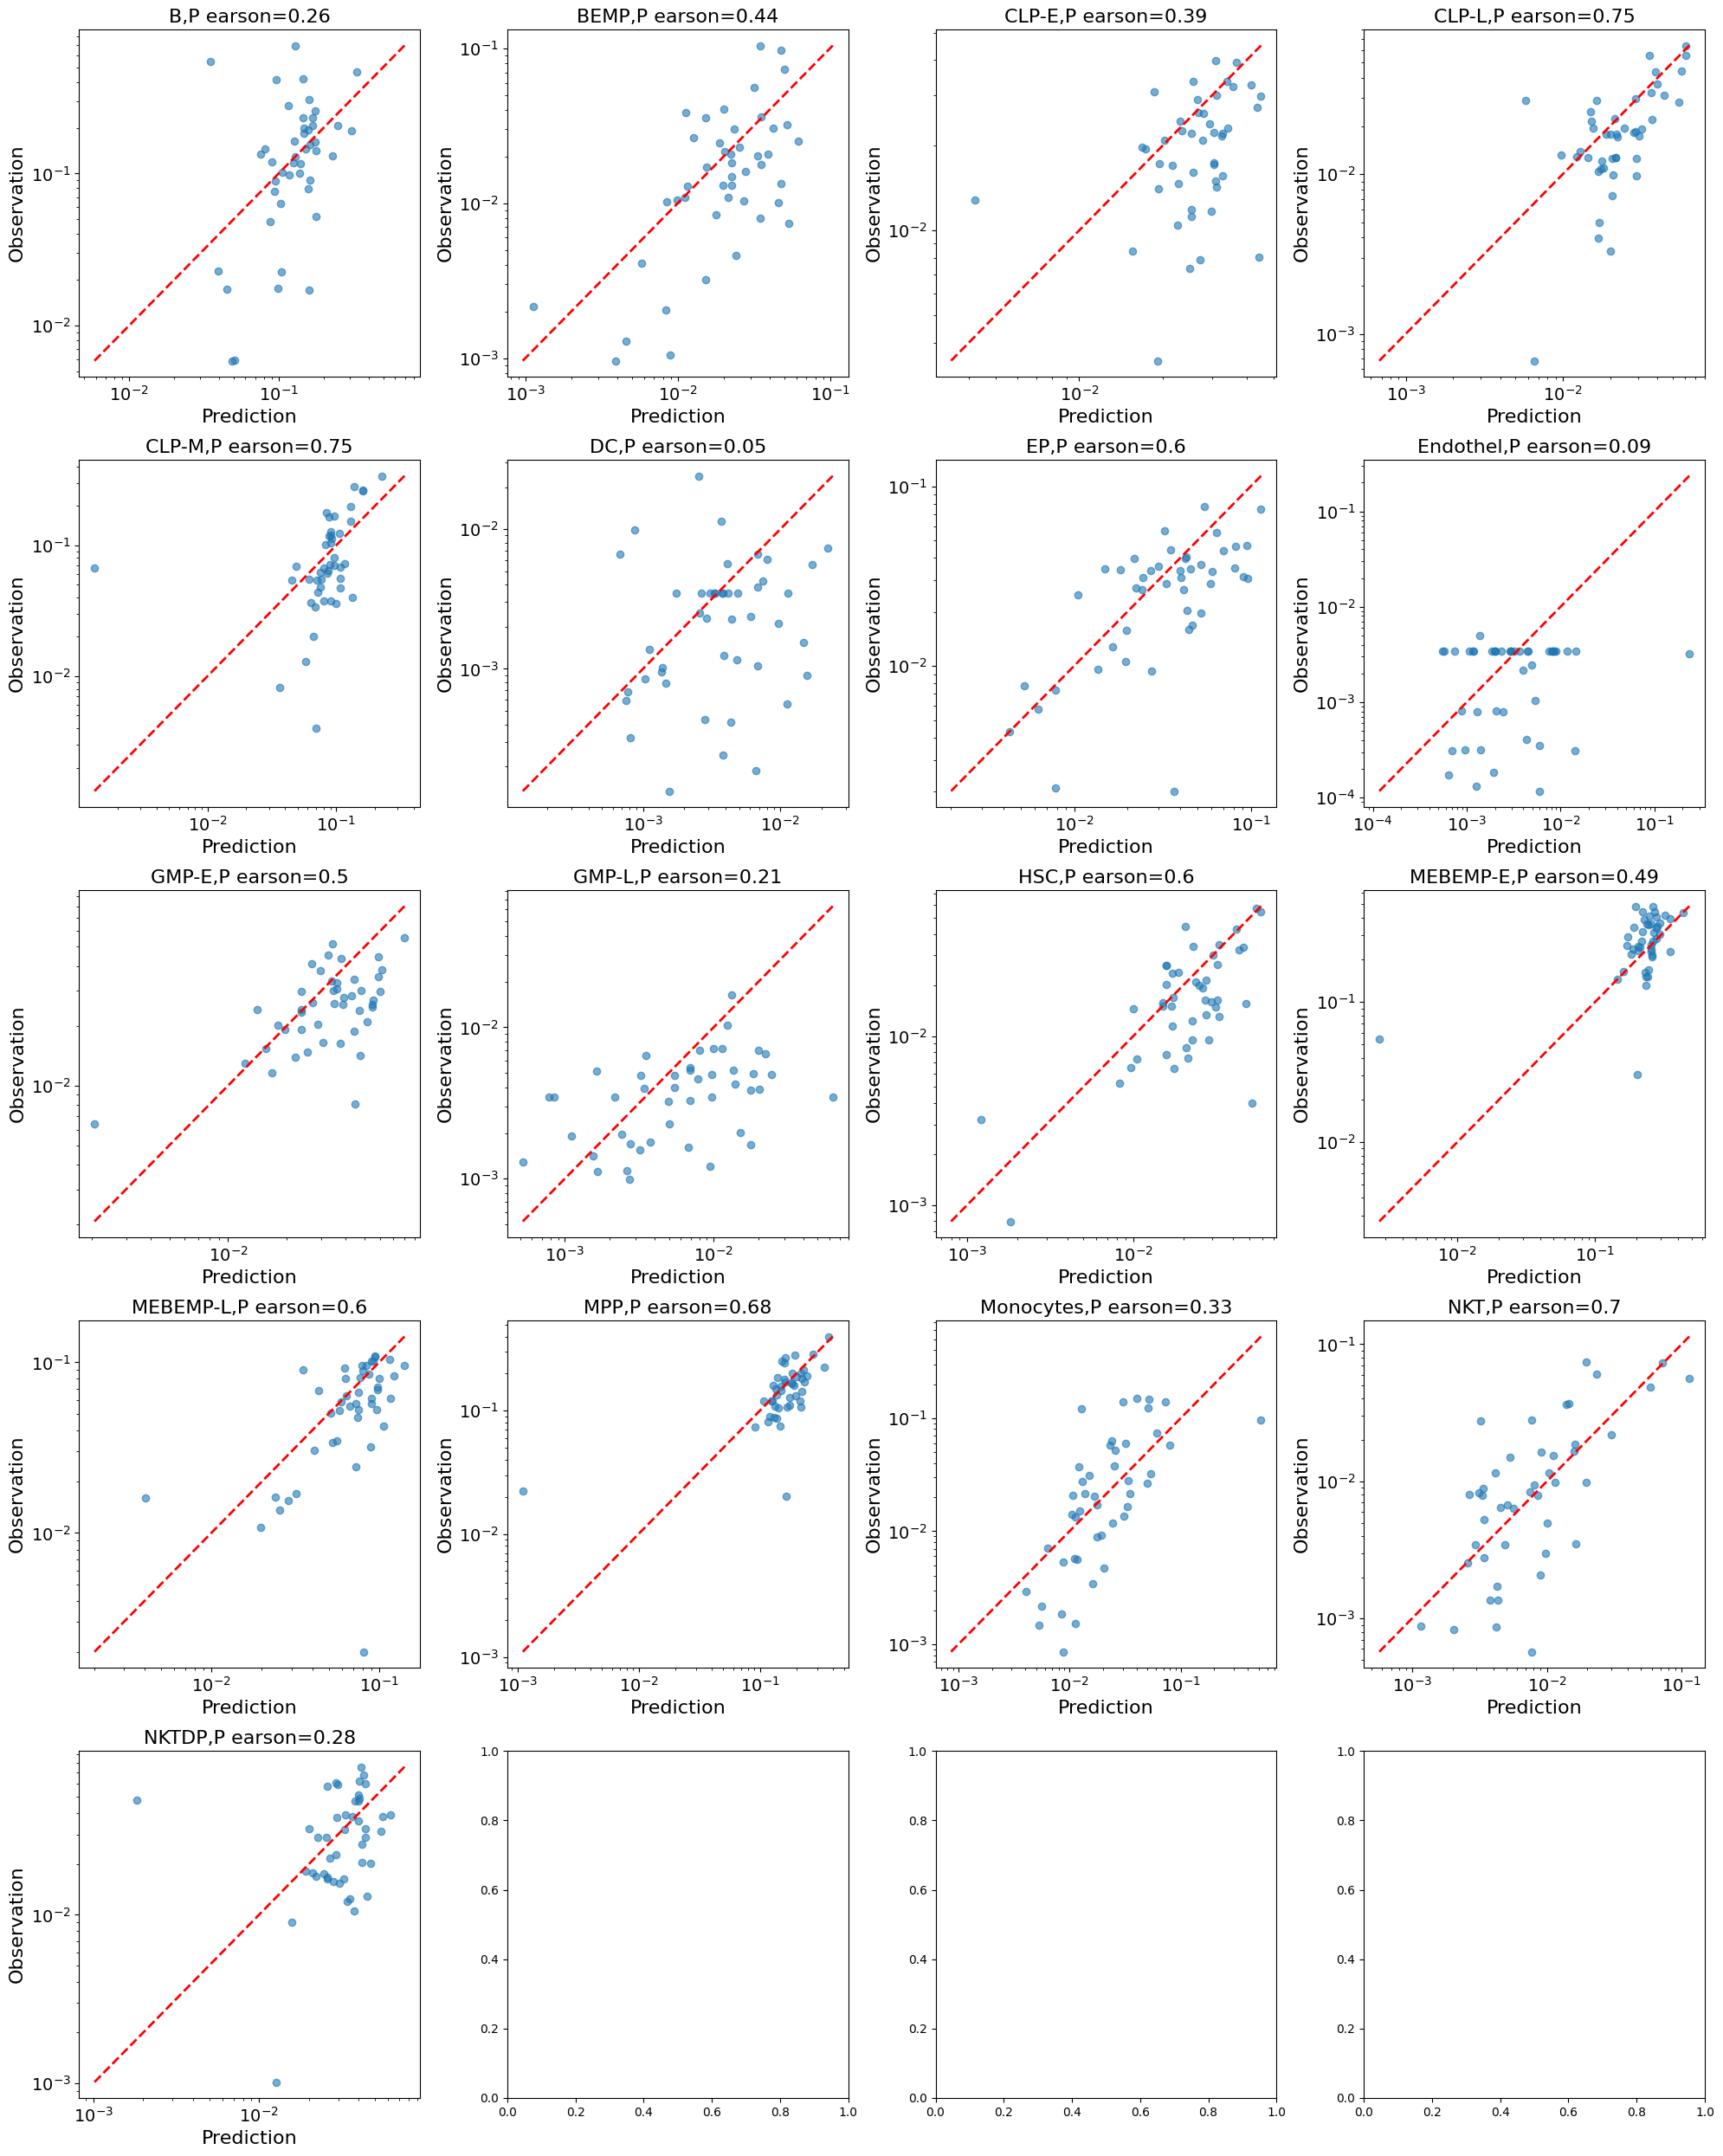

In [45]:
ncols = 4
nrows = round(test_targets.shape[1]/ncols) + 1

ct_preds = ilr_inv(test_preds)
ct_obs = ilr_inv(test_targets)

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(cell_type_proportions_df.shape[1]):
    axs[i].scatter(ct_preds[:, i].ravel(), ct_obs[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction', fontsize = 16)
    axs[i].set_ylabel('Observation', fontsize = 16)
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]},P earson={np.round(np.corrcoef(ct_preds[:, i], ct_obs[:, i])[0][1], decimals = 2)}", fontsize = 16)
    axs[i].tick_params(axis = 'both', labelsize = 14)

    min_val = min(ct_preds[:, i].min(), ct_obs[:, i].min())
    max_val = max(ct_preds[:, i].max(), ct_obs[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

# check correlation among folds and compare to pseudobulk 

In [46]:
import pickle
import os
from skbio.stats.composition import ilr, ilr_inv, clr
import numpy as np
import pandas as pd

filename_pkl = "forloopMLP"
# file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning'

file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/forloop/linear'
file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/forloop/non_linear'
file_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/forloop/linear_redo'

def get_correlation(pred: np.ndarray, obs:np.ndarray):        
    cor_list = [np.corrcoef(pred[:, i], obs[:, i], rowvar=False)[0][1] for i in range(pred.shape[1])]
    return cor_list

def dict_to_df(d: dict[str, np.ndarray]) -> pd.DataFrame:
    max_length = max([len(d[k]) for k in d.keys()])
    M = np.full((max_length, len(d.keys())), np.nan, dtype = np.float32)
    for j, k in enumerate(d.keys()):        
        M[:len(d[k]), j] = d[k]
    M = pd.DataFrame(M, columns = d.keys())
    return M
        

In [47]:
ilr_by_fold = {}
clr_by_fold = {}
celltype_by_fold = {}
nfolds = 5
for fold in np.arange(start = 1, stop = nfolds+1):
    
    file_path = os.path.join(file_dir, f"{filename_pkl}_{fold}.pkl")

    with open(file_path, 'rb') as f:
        result = pickle.load(f)

    targets = result['test_res']['targets']
    preds = result['test_res']['preds']
    
    test_targets = targets.numpy()
    test_preds = preds.numpy()

    ct_preds = ilr_inv(test_preds)
    ct_obs = ilr_inv(test_targets)

    ilr_cor_list = get_correlation(test_preds, test_targets)
    clr_cor_list = get_correlation(clr(ct_preds), clr(ct_obs))
    celltype_cor_list = get_correlation(ct_preds, ct_obs)

    ilr_by_fold[f"fold_{fold}"] = ilr_cor_list
    clr_by_fold[f"fold_{fold}"] = clr_cor_list
    celltype_by_fold[f"fold_{fold}"] = celltype_cor_list

In [48]:
result['trainer'].model

CompositionModel(
  (preprocessor): Preprocessor()
  (aggregator): Aggregator()
  (postprocessor): Postprocessor()
  (cell_predictor): CellPredictor(
    (network): Sequential(
      (0): Linear(in_features=17450, out_features=16, bias=True)
    )
  )
)

In [49]:
clr_df = dict_to_df(clr_by_fold)
celltype_df = dict_to_df(celltype_by_fold)

In [50]:
celltype_df['cors_comp_mean_MLP'] = celltype_df.mean(axis = 1)
celltype_df['cors_comp_std_MLP'] = celltype_df.std(axis = 1)
celltype_df['celltype'] = cell_type_proportions_df.columns.tolist()

In [51]:
clr_df['cors_clr_mean_MLP'] = clr_df.mean(axis = 1)
clr_df['cors_clr_std_MLP'] = clr_df.std(axis = 1)
clr_df['celltype'] = cell_type_proportions_df.columns.tolist()

In [52]:
clr_df.head()

,fold_1,fold_2,fold_3,fold_4,fold_5,cors_clr_mean_MLP,cors_clr_std_MLP,celltype
0,0.504694,0.569965,0.556176,0.503135,0.552429,0.537280,0.027866,B
1,0.789046,0.809817,0.676586,0.692753,0.741144,0.741869,0.051995,BEMP
2,0.390904,0.417213,0.670794,0.593105,0.583183,0.531040,0.108348,CLP-E
3,0.561785,0.668393,0.699428,0.683302,0.619401,0.646462,0.050092,CLP-L
4,0.557098,0.567579,0.642839,0.336638,0.568622,0.534555,0.103591,CLP-M


In [53]:
ilr_df = dict_to_df(ilr_by_fold)

In [54]:
ilr_df.head()

,fold_1,fold_2,fold_3,fold_4,fold_5
0,0.711693,0.727753,0.639298,0.606379,0.784763
1,0.524772,0.609048,0.657028,0.658585,0.413085
2,0.522897,0.760420,0.574661,0.730856,0.402258
3,0.611936,0.616393,0.413363,0.321515,0.503432
4,0.023744,0.094086,0.430169,0.267105,0.184623


In [55]:
import pickle
import numpy as np

with open("HSC_MPP_regression.pkl", "rb") as f:
    HSC_MPP_regression = pickle.load(f)

# with open("B_regression.pkl", "rb") as f:
#     HSC_MPP_regression = pickle.load(f)
    
# metrics = ['cors_comp']
metrics = ['cors_clr_comp', 'cors_comp']
all_rows_linear = []
nfolds = 5

pseudobulk_ilr = {}

for fold in np.arange(nfolds):
    fitting_res_dict = HSC_MPP_regression[fold+1]    
  
    K = celltype_df.shape[0]
    celltypes = cell_type_proportions_df.columns.tolist()
    assert K == len(celltypes), "Mismatch between metrics length and number of cell types"

    for i in range(K):
        row = {
            'fold': fold,
            'celltype': celltypes[i],
        }
        for m in metrics:
            row[m] = fitting_res_dict[m][i]
        all_rows_linear.append(row)
    
    # doing for ilr
    test_ilr = ilr(fitting_res_dict['Y_test_comp_df'])
    obs_ilr = ilr(fitting_res_dict['Y_obs_comp_df'])
    pseudobulk_ilr[f'fold_{fold+1}'] = [np.corrcoef(test_ilr[:, i], obs_ilr[:, i], rowvar = False)[0][1] for i in range(test_ilr.shape[1])]

df_long_linear = pd.DataFrame(all_rows_linear)
print(df_long_linear.head())


   fold celltype  cors_clr_comp  cors_comp
0     0        B       0.551128   0.644776
1     0     BEMP       0.722919   0.687946
2     0    CLP-E       0.542364   0.438066
3     0    CLP-L       0.742041   0.624261
4     0    CLP-M       0.653651   0.735733


/tmp/ipykernel_3688740/1210705048.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row[m] = fitting_res_dict[m][i]


In [56]:
ilr_pseudobulk_df = dict_to_df(pseudobulk_ilr)

In [57]:
ilr_pseudobulk_df.head()

,fold_1,fold_2,fold_3,fold_4,fold_5
0,0.677066,0.705839,0.677189,0.744283,0.722544
1,0.621956,0.589788,0.633634,0.602148,0.611477
2,0.812182,0.604449,0.670527,0.734939,0.662202
3,0.712779,0.781752,0.626986,0.700797,0.634695
4,0.314376,0.084459,0.431053,0.486972,0.084138


In [58]:
# 1) group and aggregate
agg_linear = df_long_linear.groupby('celltype')[metrics].agg(['mean', 'std', 'count']).reset_index()

# 2) flatten MultiIndex columns
agg_linear.columns = ['celltype'] + [f"{metric}_{stat}" for metric, stat in agg_linear.columns[1:]]


In [59]:
agg_linear.head()

,celltype,cors_clr_comp_mean,cors_clr_comp_std,cors_clr_comp_count,cors_comp_mean,cors_comp_std,cors_comp_count
0,B,0.568724,0.040875,5,0.566874,0.091041,5
1,BEMP,0.758180,0.045727,5,0.653459,0.052678,5
2,CLP-E,0.504883,0.079246,5,0.470071,0.083666,5
3,CLP-L,0.686519,0.071266,5,0.627940,0.047539,5
4,CLP-M,0.672702,0.100187,5,0.708376,0.082376,5


  celltype  cors_clr_comp_mean  cors_clr_comp_std  cors_clr_comp_count  \
0        B            0.568724           0.040875                    5   
1     BEMP            0.758180           0.045727                    5   
2    CLP-E            0.504883           0.079246                    5   
3    CLP-L            0.686519           0.071266                    5   
4    CLP-M            0.672702           0.100187                    5   

   cors_comp_mean  cors_comp_std  cors_comp_count  cors_clr_comp_sem  \
0        0.566874       0.091041                5           0.018280   
1        0.653459       0.052678                5           0.020450   
2        0.470071       0.083666                5           0.035440   
3        0.627940       0.047539                5           0.031871   
4        0.708376       0.082376                5           0.044805   

   cors_clr_comp_95ci_lower  cors_clr_comp_95ci_upper  cors_comp_sem  \
0                  0.532895                  0.604

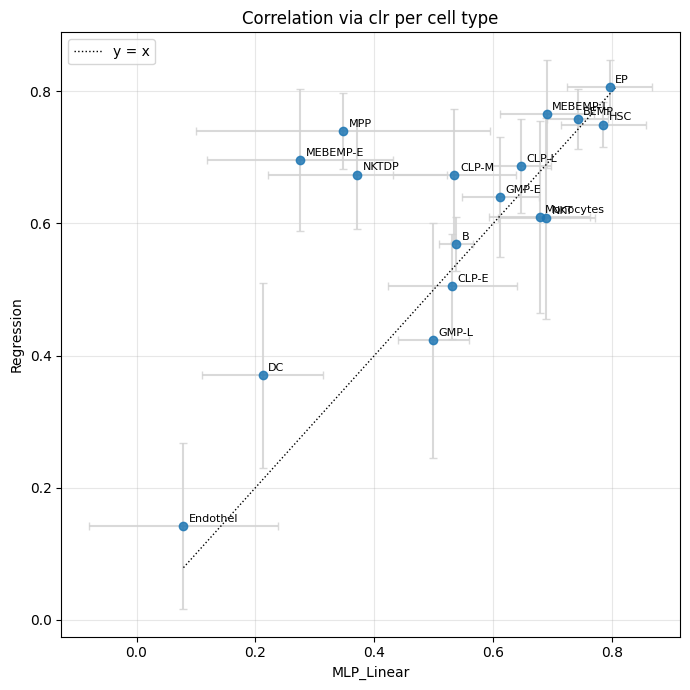

In [60]:

# 3) compute SEM and 95% CI (using normal approx; adjust if n small)
for m in metrics:
    mean_col = f"{m}_mean"
    std_col = f"{m}_std"
    cnt_col = f"{m}_count"
    sem_col = f"{m}_sem"
    ci_lo = f"{m}_95ci_lower"
    ci_hi = f"{m}_95ci_upper"

    # SEM: std / sqrt(n) (if count is 0, result becomes NaN)
    agg_linear[sem_col] = agg_linear[std_col] / np.sqrt(agg_linear[cnt_col].replace(0, np.nan))

    # 95% CI using 1.96 * SEM (normal approx)
    agg_linear[ci_lo] = agg_linear[mean_col] - 1.96 * agg_linear[sem_col]
    agg_linear[ci_hi] = agg_linear[mean_col] + 1.96 * agg_linear[sem_col]

# Example: show the table
print(agg_linear.head())


# python
# Plot error-scatter between two dataframes (agg, agg_linear) for cell-type correlations.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Helper: try to find error columns for a mean column ----------
def _find_error_columns(df, mean_col):
    """
    Given df and mean_col (e.g., 'clr_cor_t_mean'), try to find:
      - symmetric error column (std or sem) -> returns ('sym', colname) or None
      - asymmetric CI columns (lower, upper) -> returns ('asym', (low_col, up_col)) or None
    """
    # candidates for symmetric error
    sym_candidates = [
        mean_col.replace('_mean', '_std'),
        mean_col.replace('_mean', '_sem'),
        mean_col + '_std',
        mean_col + '_sem'
    ]
    for c in sym_candidates:
        if c in df.columns:
            return ('sym', c)

    # candidates for asymmetric CI (lower/upper)
    low_candidates = [
        mean_col.replace('_mean', '_95ci_lower'),
        mean_col.replace('_mean', '_ci_lower'),
        mean_col + '_95ci_lower',
    ]
    up_candidates = [
        mean_col.replace('_mean', '_95ci_upper'),
        mean_col.replace('_mean', '_ci_upper'),
        mean_col + '_95ci_upper',
    ]
    for low in low_candidates:
        for up in up_candidates:
            if low in df.columns and up in df.columns:
                return ('asym', (low, up))

    # nothing found
    return (None, None)

def _get_errors_from_df(df, mean_col):
    """
    Returns either:
      - None, None if no error info
      - symmetric_errors (1d numpy array), None
      - None, asymmetric_errors (2 x N numpy array: [lower, upper])
    Lower/upper are positive distances from the mean.
    """
    typ, col = _find_error_columns(df, mean_col)
    mean_vals = df[mean_col].to_numpy(dtype=float)

    if typ == 'sym':
        sym = df[col].to_numpy(dtype=float)
        # Ensure non-negative
        sym = np.maximum(sym, 0.0)
        return sym, None
    elif typ == 'asym':
        low_col, up_col = col
        low = df[low_col].to_numpy(dtype=float)
        up = df[up_col].to_numpy(dtype=float)
        # Convert to distances from mean (in case columns were absolute bounds)
        lower_err = np.clip(mean_vals - low, 0.0, None)
        upper_err = np.clip(up - mean_vals, 0.0, None)
        return None, np.vstack([lower_err, upper_err])
    else:
        return None, None

# ---------- Main plotting function ----------
def plot_error_scatter(agg, agg_linear,
                       mean_col1='clr_cor_t_mean',
                       mean_col2='cors_clr_comp_mean',
                       celltype_col='celltype',
                       title='Correlation per cell type',
                       annotate=True,
                       figsize=(7,7),
                       savepath=None):
    """
    Merge agg and agg_linear on celltype_col and plot mean_col1 (x) vs mean_col2 (y)
    with error bars if available.
    Returns merged DataFrame and the matplotlib Figure.
    """
    # merge
    merged = pd.merge(agg, agg_linear, on=celltype_col, how='inner', suffixes=('_pytorch','_analytical'))
    if mean_col1 not in merged.columns:
        raise KeyError(f"{mean_col1} not found in merged dataframe columns: {merged.columns.tolist()}")
    if mean_col2 not in merged.columns:
        raise KeyError(f"{mean_col2} not found in merged dataframe columns: {merged.columns.tolist()}")

    # drop rows with NaN in mean cols
    merged = merged.dropna(subset=[mean_col1, mean_col2]).reset_index(drop=True)

    x = merged[mean_col1].to_numpy(dtype=float)
    y = merged[mean_col2].to_numpy(dtype=float)

    # errors for x and y (symmetric or asymmetric)
    x_sym, x_asym = _get_errors_from_df(merged, mean_col1)
    y_sym, y_asym = _get_errors_from_df(merged, mean_col2)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    # Choose errorbar parameters depending on availability
    err_kwargs = {}
    if x_asym is not None:
        err_kwargs['xerr'] = x_asym
    elif x_sym is not None:
        err_kwargs['xerr'] = x_sym
    if y_asym is not None:
        err_kwargs['yerr'] = y_asym
    elif y_sym is not None:
        err_kwargs['yerr'] = y_sym

    # Basic scatter with error bars (if any)
    ax.errorbar(x, y, fmt='o', ecolor='lightgray', alpha=0.85, capsize=3, markersize=6, **err_kwargs)

    # diagonal and fit line
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    ymin, ymax = np.nanmin(y), np.nanmax(y)
    low = min(xmin, ymin)
    high = max(xmax, ymax)
    line_x = np.linspace(low, high, 200)
    ax.plot(line_x, line_x, color='k', linestyle=':', linewidth=1, label='y = x')
    # if not np.isnan(m):
    #     ax.plot(line_x, m*line_x + b, color='C1', linestyle='--', linewidth=1, label=f'fit: y={m:.2f}x+{b:.2f}')

    # annotations
    if annotate:
        for xi, yi, label in zip(x, y, merged[celltype_col].astype(str)):
            ax.annotate(label, (xi, yi), xytext=(4, 3), textcoords='offset points', fontsize=8)
    if mean_col1 in (['cors_clr_mean_MLP', 'cors_comp_mean_MLP']):
        ax.set_xlabel("MLP_Linear")
    else:
        ax.set_xlabel(mean_col1)

    if mean_col2 in (['cors_clr_comp_mean', 'Rsq_clr_comp_mean']):
        ax.set_ylabel("Regression")
    else:
        ax.set_ylabel(mean_col2)
    ax.set_title(title)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    # show pearson text
    # ax.text(0.02, 0.98, pearson_text, transform=ax.transAxes, va='top', fontsize=9)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=300)

    return merged, fig

# ---------- Example usage ----------
merged_df, fig = plot_error_scatter(clr_df, agg_linear,
                                   mean_col1='cors_clr_mean_MLP',
                                   mean_col2='cors_clr_comp_mean',
                                   celltype_col='celltype',
                                   title='Correlation via clr per cell type',
                                   annotate=True,
                                   savepath=None)
plt.show()

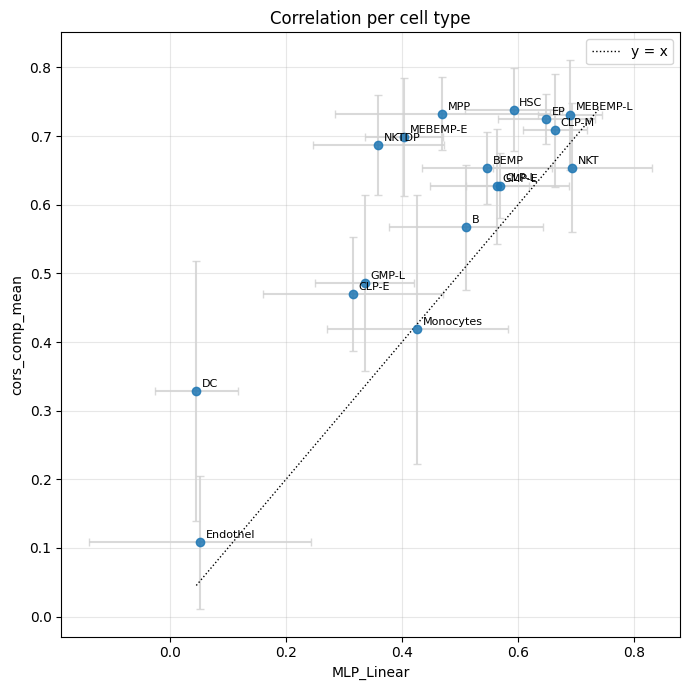

In [61]:
merged_df, fig = plot_error_scatter(celltype_df, agg_linear,
                                   mean_col1='cors_comp_mean_MLP',
                                   mean_col2='cors_comp_mean',
                                   celltype_col='celltype',
                                   title='Correlation per cell type',
                                   annotate=True,
                                   savepath=None)
plt.show()

In [31]:
# plot ilr comparison 

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_row_mean_ci(df: pd.DataFrame, fold_cols: list[str], alpha: float = 0.05):
    """
    Compute per-row mean, std, count, SEM and 95% CI over fold columns.
    Returns a DataFrame with columns: ['mean', 'std', 'count', 'sem', 'ci_lower', 'ci_upper'].
    """
    # Coerce selected columns to numeric, invalid strings -> NaN
    df_numeric = df[fold_cols].apply(pd.to_numeric, errors="coerce")

    # Count non-NaN entries per row
    count = df_numeric.notna().sum(axis=1).astype(int)
    # Mean/std across folds (ignore NaNs). Use ddof=1 for sample std if count>1.
    mean = df_numeric.mean(axis=1, skipna=True)
    std = df_numeric.std(axis=1, ddof=1, skipna=True)

    # SEM = std / sqrt(n); NaN where n<=1
    sem = std / np.sqrt(count.replace(0, np.nan))

    # 95% CI: mean ± tcrit * sem if possible; else normal approx
    try:
        from scipy.stats import t
        # t critical per row: handle n<=1 -> NaN
        dfree = (count - 1).astype(float)
        tcrit = pd.Series(np.nan, index=df.index)
        ok = dfree > 0
        tcrit.loc[ok] = t.ppf(1 - alpha/2, df=dfree[ok])
        ci_lower = mean - tcrit * sem
        ci_upper = mean + tcrit * sem
    except ImportError:
        # Fallback to normal approx 1.96
        z = 1.96
        ci_lower = mean - z * sem
        ci_upper = mean + z * sem

    return pd.DataFrame({
        "mean": mean,
        "std": std,
        "count": count,
        "sem": sem,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
    }, index=df.index)

def plot_fold_mean_ci_compare(ilr_pseudobulk_df: pd.DataFrame,
                              ilr_df: pd.DataFrame,
                              fold_cols: list[str] = None,
                              label_col: str | None = None,
                              title: str = "Fold-wise mean and 95% CI: pseudobulk (y) vs linear (x)",
                              annotate: bool = True,
                              figsize=(7, 7),
                              savepath: str | None = None):
    """
    Compute per-row mean and 95% CI in two dataframes, then plot a scatter:
      x = ilr_df mean (with its 95% CI as x-error)
      y = ilr_pseudobulk_df mean (with its 95% CI as y-error)

    - If label_col is provided, merge on that column; else align by index.
    - Returns merged summary DataFrame and the matplotlib Figure/Axes.
    """
    # Default fold columns: any column matching 'fold_' prefix
    if fold_cols is None:
        fold_cols_ilr = [c for c in ilr_df.columns if str(c).startswith("fold_")]
        fold_cols_pseudo = [c for c in ilr_pseudobulk_df.columns if str(c).startswith("fold_")]
    else:
        fold_cols_ilr = fold_cols
        fold_cols_pseudo = fold_cols

    # Compute summaries
    sum_ilr   = compute_row_mean_ci(ilr_df, fold_cols_ilr)
    sum_pseudo= compute_row_mean_ci(ilr_pseudobulk_df, fold_cols_pseudo)

    # Attach labels for merging if provided
    if label_col is not None:
        if label_col not in ilr_df.columns or label_col not in ilr_pseudobulk_df.columns:
            raise KeyError(f"label_col '{label_col}' not found in both dataframes.")
        sum_ilr = sum_ilr.join(ilr_df[[label_col]])
        sum_pseudo = sum_pseudo.join(ilr_pseudobulk_df[[label_col]])
        merged = pd.merge(sum_ilr, sum_pseudo, on=label_col, suffixes=("_x", "_y"))
        labels = merged[label_col].astype(str).tolist()
    else:
        # Align by index
        merged = sum_ilr.join(sum_pseudo, lsuffix="_x", rsuffix="_y")
        labels = [str(idx) for idx in merged.index]

    # Extract values
    x_mean = merged["mean_x"].to_numpy(dtype=float)
    y_mean = merged["mean_y"].to_numpy(dtype=float)
    # Errors: use asymmetric (lower/upper as distances from mean)
    xerr = np.vstack([
        np.clip(x_mean - merged["ci_lower_x"].to_numpy(dtype=float), 0.0, None),
        np.clip(merged["ci_upper_x"].to_numpy(dtype=float) - x_mean, 0.0, None)
    ])
    yerr = np.vstack([
        np.clip(y_mean - merged["ci_lower_y"].to_numpy(dtype=float), 0.0, None),
        np.clip(merged["ci_upper_y"].to_numpy(dtype=float) - y_mean, 0.0, None)
    ])

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(x_mean, y_mean, xerr=xerr, yerr=yerr, fmt="o",
                ecolor="gray", elinewidth=1, capsize=3, color="tab:blue", alpha=0.9)

    # Diagonal y=x reference
    lo = np.nanmin([np.nanmin(x_mean - xerr[0]), np.nanmin(y_mean - yerr[0])])
    hi = np.nanmax([np.nanmax(x_mean + xerr[1]), np.nanmax(y_mean + yerr[1])])
    pad = 0.05 * (hi - lo) if np.isfinite(hi - lo) else 1.0
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", lw=1, color="k", alpha=0.6)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)

    # Optional annotations
    if annotate:
        for xi, yi, lab in zip(x_mean, y_mean, labels):
            if np.isfinite(xi) and np.isfinite(yi):
                ax.text(xi, yi, f" {lab}", fontsize=8, va="center", ha="left")

    # Pearson between means
    mask = np.isfinite(x_mean) & np.isfinite(y_mean)
    if mask.sum() >= 2:
        xm = x_mean[mask] - x_mean[mask].mean()
        ym = y_mean[mask] - y_mean[mask].mean()
        denom = np.sqrt((xm**2).sum() * (ym**2).sum())
        r = float((xm * ym).sum() / denom) if denom != 0 else np.nan
        ax.set_title(f"{title}\nPearson r = {r:.3f}")
    else:
        ax.set_title(title)

    ax.set_xlabel("MLP_Linear")
    ax.set_ylabel("Regression")
    ax.grid(True, alpha=0.2)

    if savepath:
        fig.tight_layout()
        fig.savefig(savepath, dpi=150)
    else:
        fig.tight_layout()
        plt.show()

    return merged, (fig, ax)

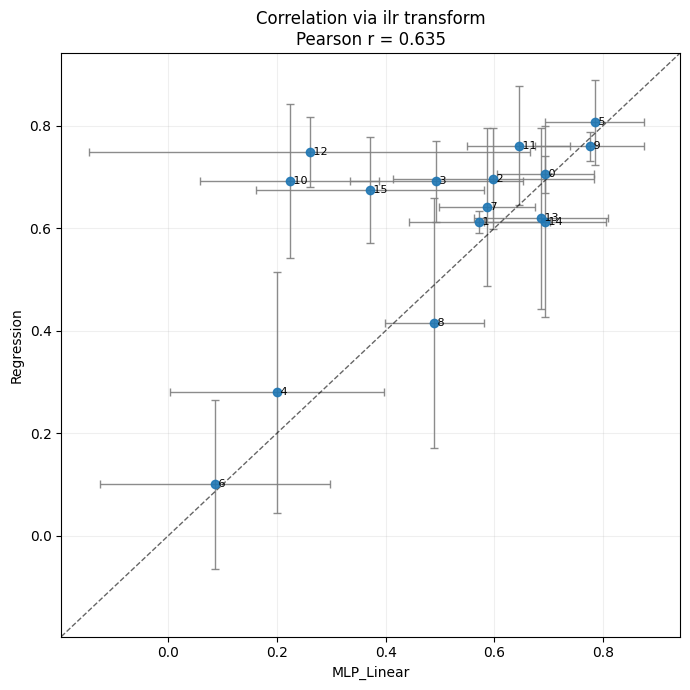

In [64]:
merged, (fig, ax) = plot_fold_mean_ci_compare(ilr_pseudobulk_df, ilr_df, title="Correlation via ilr transform")